In [2]:
# import the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data inspection

In [3]:
# load the data
file_path = "Data_exp2.xlsx"  
df = pd.read_excel(file_path)
# quick check
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3613 entries, 0 to 3612
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   ImageNumber      3613 non-null   int64 
 1   Hominess         3613 non-null   int64 
 2   PredHominess     3613 non-null   object
 3   Naturalness      3613 non-null   int64 
 4   Personalness     3613 non-null   int64 
 5   Beauty           3613 non-null   int64 
 6   Approachability  3613 non-null   int64 
 7   Participant      3613 non-null   int64 
dtypes: int64(7), object(1)
memory usage: 225.9+ KB
None


In [3]:
# check the size of the data frame
size_dim = df.shape
print(f"The size of this data frame: {size_dim}")
# check if there are missing values
missing_rows = df.isnull().any(axis=1).sum()
print(f"Number of rows with missing values: {missing_rows}")
# Count unique participants
print(f"We have {df['Participant'].nunique()} unique participants.")

The size of this data frame: (3613, 8)
Number of rows with missing values: 0
We have 46 unique participants.


In [4]:
df['Participant'].value_counts()

Participant
1     80
2     80
27    80
28    80
29    80
30    80
31    80
32    80
33    80
34    80
35    80
36    80
37    80
38    80
39    80
40    80
41    80
42    80
43    80
44    80
45    80
25    80
24    80
23    80
12    80
3     80
4     80
5     80
6     80
7     80
8     80
9     80
10    80
11    80
13    80
22    80
14    80
15    80
16    80
17    80
18    80
19    80
20    80
46    80
21    53
26    40
Name: count, dtype: int64

Participant 21&26 finished 53 and 40 trials respectively, while others finished all the trials.

In [4]:
# check the conditions
df = df.rename(columns={'PredHominess': 'Category'}).astype({'Category': 'category'})
df['Category'].unique()

['Plus', 'Minus']
Categories (2, object): ['Minus', 'Plus']

We only have Plus and Minus for the image category.

In [6]:
# adding one more variable: the group, particiapnt 1-23 are in group ASD, and participant 24-46 are in group control
df['Group'] = df['Participant'].apply(lambda x: 'ASD' if x <= 23 else 'Control')
df.groupby('Group')['Participant'].nunique()

Group
ASD        23
Control    23
Name: Participant, dtype: int64

In [14]:
# compute the mean value for each category and group for each dimension
mean_values = df.groupby(['Group', 'Category']).mean().reset_index()
print(mean_values)

     Group Category  ImageNumber  Hominess  Naturalness  Personalness  \
0      ASD    Minus    46.147124  3.213496     2.507743      3.036504   
1      ASD     Plus    34.826183  4.499450     5.217822      4.611661   
2  Control    Minus    46.133185  3.085461     2.269700      2.912320   
3  Control     Plus    34.784205  5.457175     6.023359      5.503893   

     Beauty  Approachability  Participant  
0  3.556416         4.011062    11.840708  
1  5.446645         5.708471    11.891089  
2  3.742508         4.294118    35.189789  
3  6.420467         6.553949    35.210234  


C:\Users\yyang\AppData\Local\Temp\ipykernel_20232\3933856604.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_values = df.groupby(['Group', 'Category']).mean().reset_index()


In [7]:
rating_cols = ['Hominess', 'Naturalness', 'Personalness', 'Beauty', 'Approachability']
# separate the data frame into two groups
ASD_df = df[df['Group'] == 'ASD']
CTRL_df = df[df['Group'] == 'Control']

In [13]:
ASD_ratings = ASD_df[rating_cols]
CTRL_ratings = CTRL_df[rating_cols]
ASD_ratings.describe()


,Hominess,Naturalness,Personalness,Beauty,Approachability
count,1813.000000,1813.000000,1813.000000,1813.000000,1813.000000
mean,3.858246,3.866520,3.826255,4.504137,4.862107
std,1.961068,2.103253,1.960182,1.993812,2.004070
min,1.000000,1.000000,1.000000,1.000000,1.000000
25%,2.000000,2.000000,2.000000,3.000000,3.000000
50%,4.000000,4.000000,4.000000,5.000000,5.000000
75%,5.000000,6.000000,5.000000,6.000000,7.000000
max,7.000000,7.000000,7.000000,7.000000,7.000000


In [12]:
CTRL_ratings.describe()

,Hominess,Naturalness,Personalness,Beauty,Approachability
count,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000
mean,4.270000,4.144444,4.206667,5.080000,5.422778
std,2.064655,2.344253,2.026111,1.951109,1.907428
min,1.000000,1.000000,1.000000,1.000000,1.000000
25%,2.000000,2.000000,2.000000,4.000000,4.000000
50%,5.000000,4.000000,4.500000,6.000000,6.000000
75%,6.000000,7.000000,6.000000,7.000000,7.000000
max,7.000000,7.000000,7.000000,7.000000,7.000000


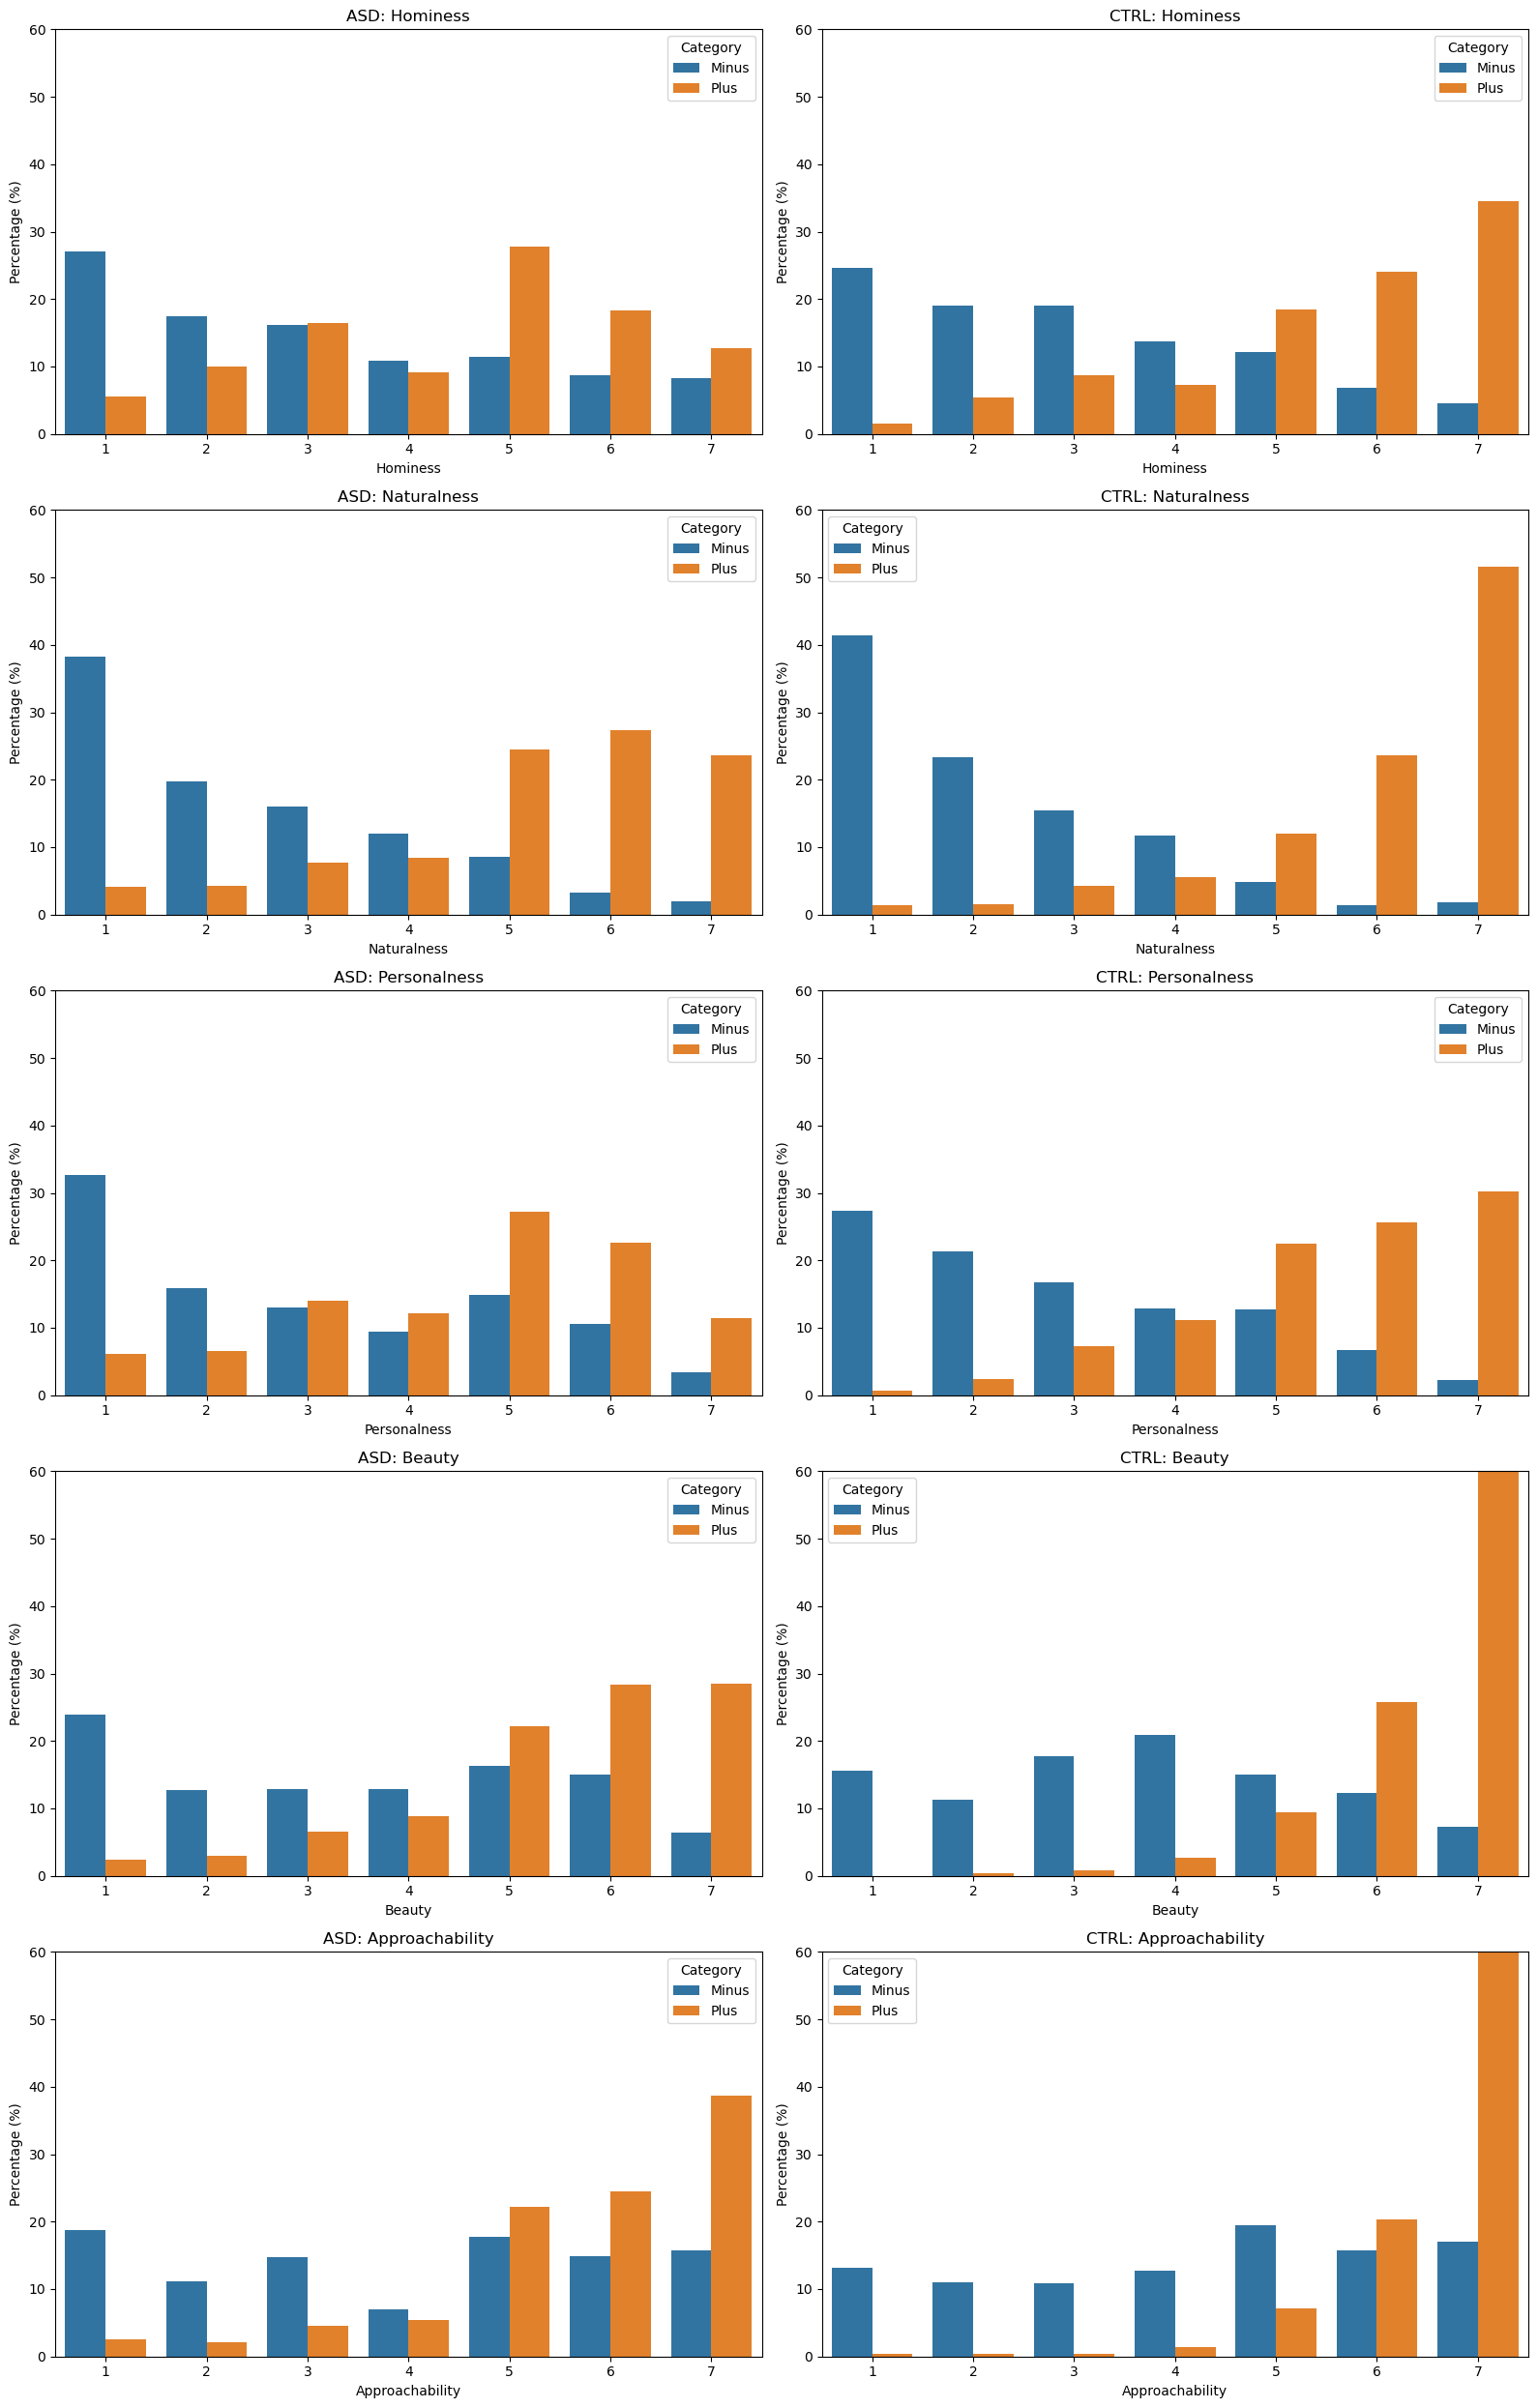

In [59]:
# Set up the 5x2 grid
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(16, 25))

for i, col in enumerate(rating_cols):
    # --- 1. Process ASD Data for the current column ---
    ASD_counts = ASD_df.groupby('Category', observed=False)[col].value_counts().sort_index().reset_index(name='counts')
    ASD_total = ASD_counts.groupby('Category', observed=False)['counts'].transform('sum')
    ASD_counts['percentage'] = (ASD_counts['counts'] / ASD_total) * 100
    
    # --- 2. Process CTRL Data for the current column ---
    CTRL_counts = CTRL_df.groupby('Category', observed=False)[col].value_counts().sort_index().reset_index(name='counts')
    CTRL_total = CTRL_counts.groupby('Category', observed=False)['counts'].transform('sum')
    CTRL_counts['percentage'] = (CTRL_counts['counts'] / CTRL_total) * 100
    
    # Define the rating scale to ensure all plots have 1-7 on the x-axis
    rating_order = [1, 2, 3, 4, 5, 6, 7]
    
    # --- 3. Plot ASD (Left Column: axes[i, 0]) ---
    sns.barplot(ax=axes[i, 0], data=ASD_counts, x=col, y='percentage', hue='Category', order=rating_order)
    axes[i, 0].set_title(f"ASD: {col}")
    axes[i, 0].set_ylabel("Percentage (%)")
    axes[i, 0].set_ylim(0, 60) # Adjust Y-limit as needed
    
    # --- 4. Plot CTRL (Right Column: axes[i, 1]) ---
    sns.barplot(ax=axes[i, 1], data=CTRL_counts, x=col, y='percentage', hue='Category', order=rating_order)
    axes[i, 1].set_title(f"CTRL: {col}")
    axes[i, 1].set_ylabel("Percentage (%)")
    axes[i, 1].set_ylim(0, 60)

# Adjust layout to prevent title/label overlap
plt.tight_layout()
plt.show()

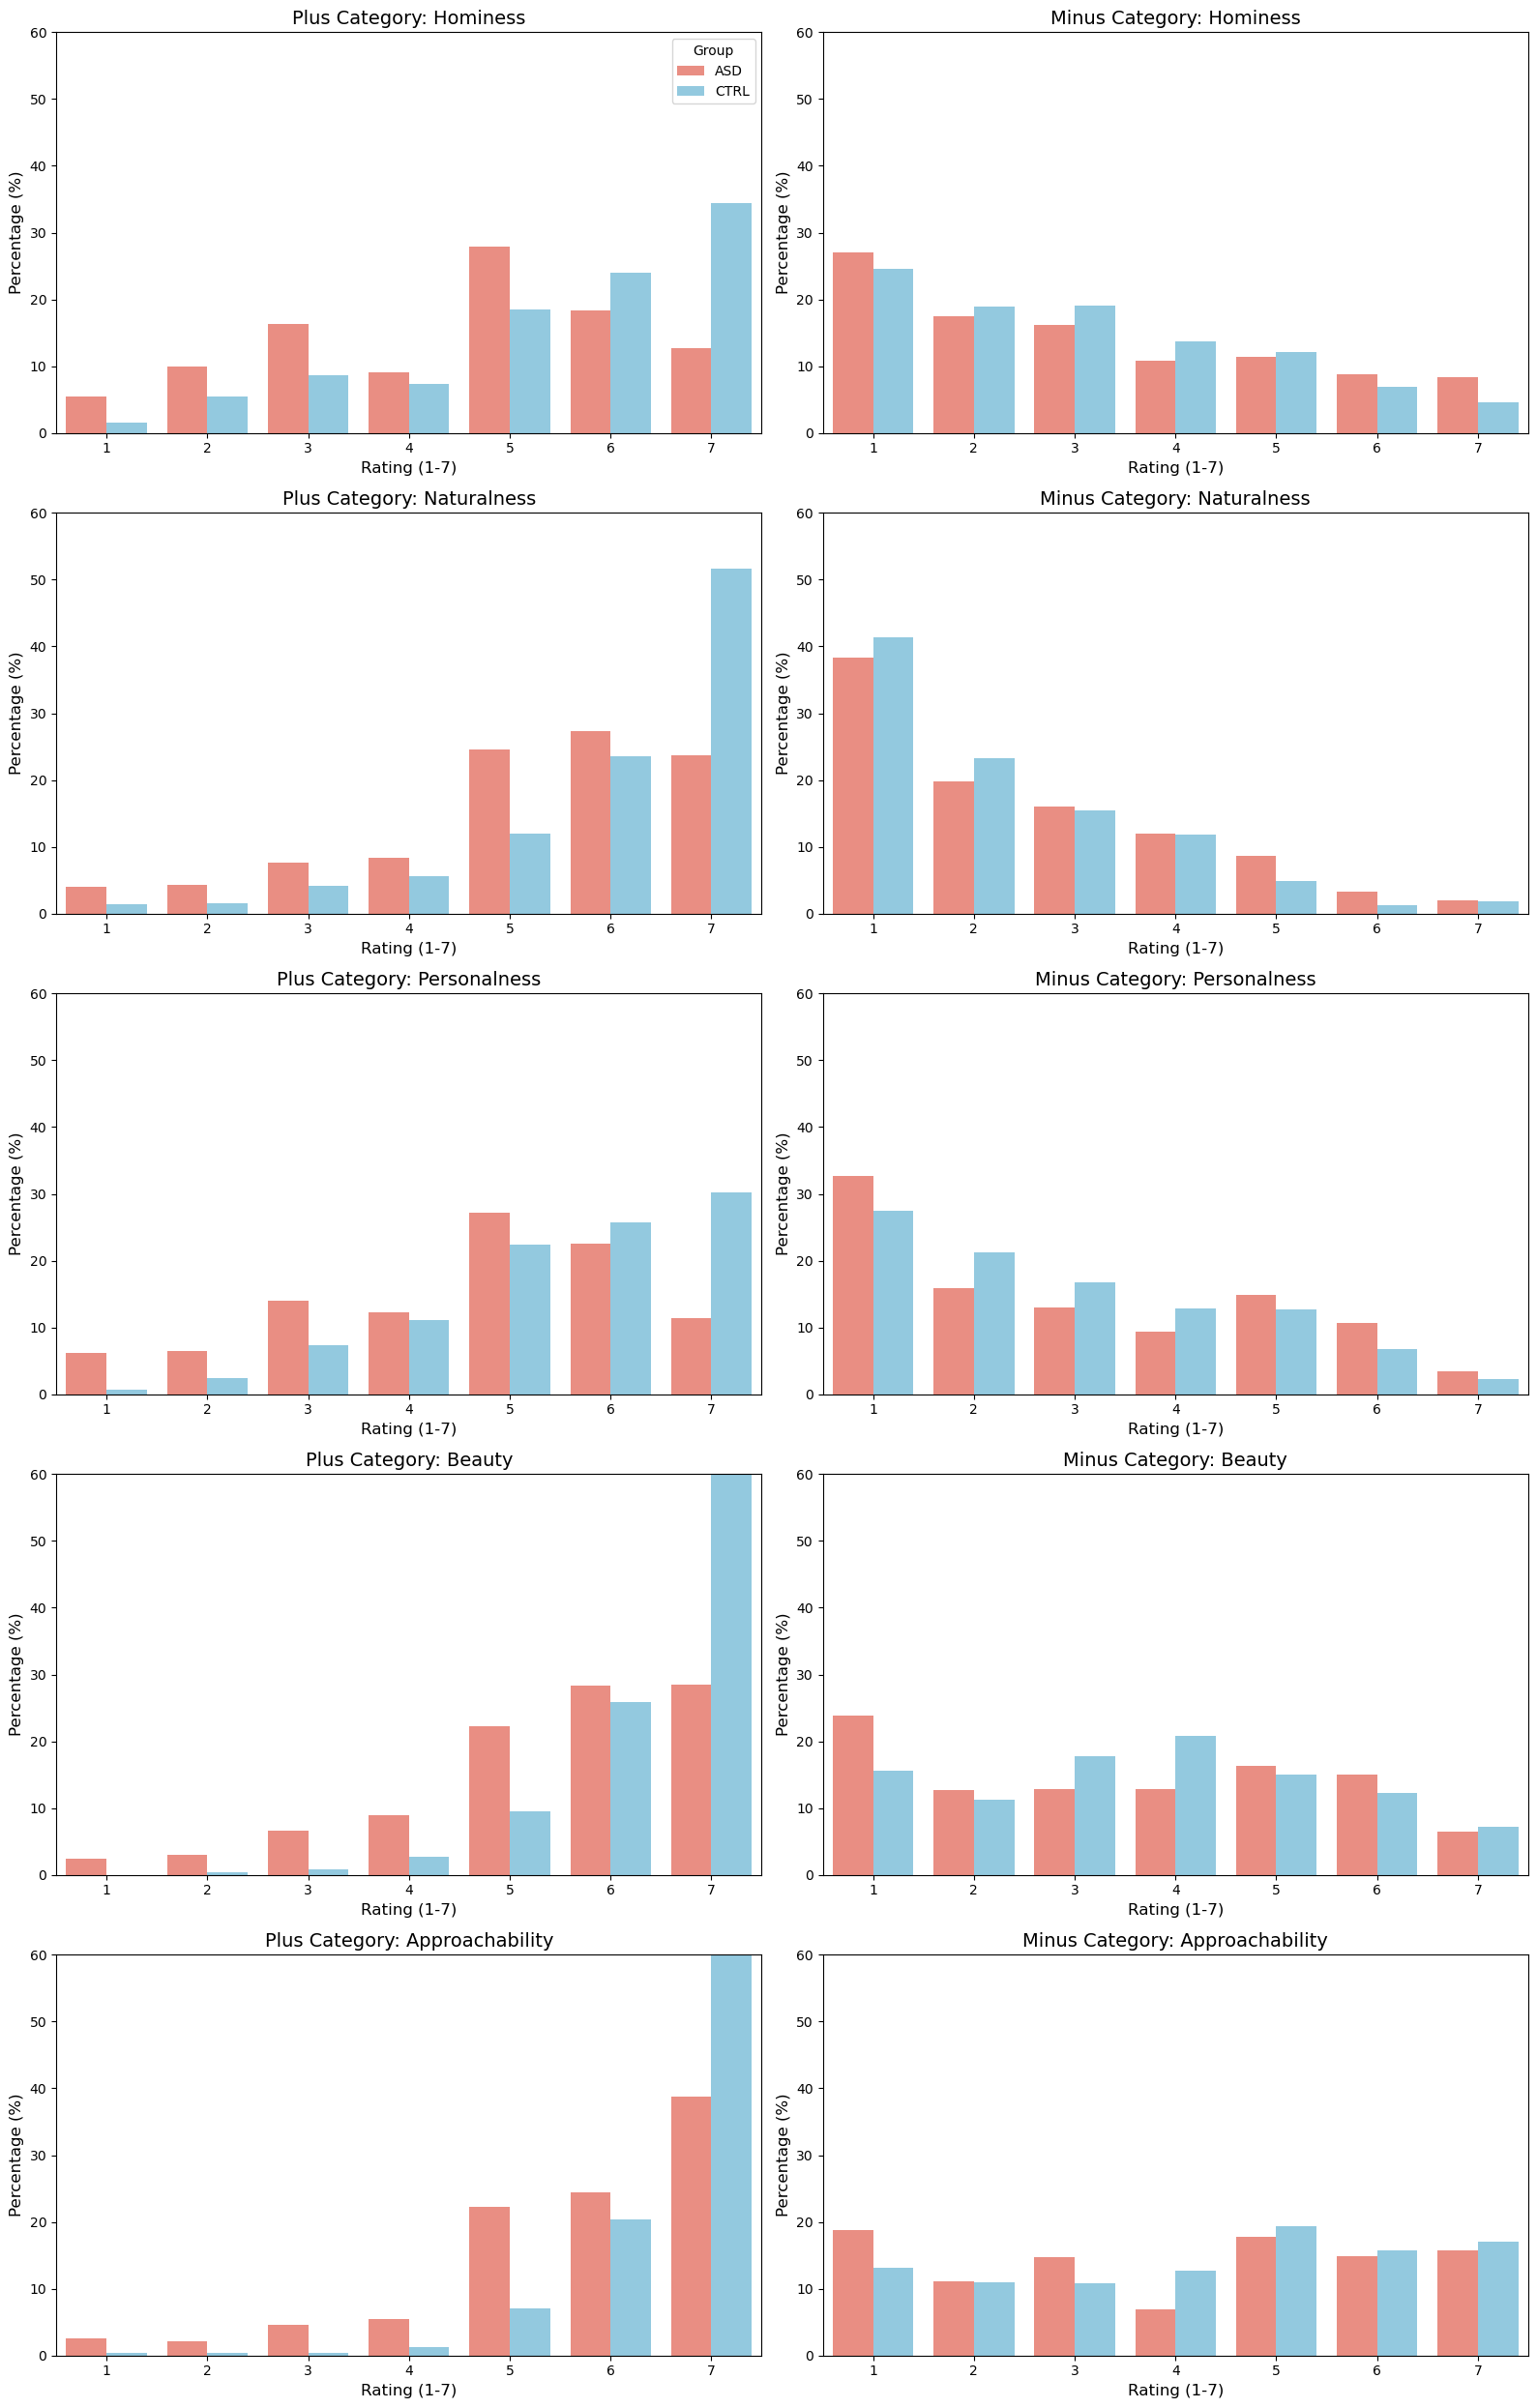

In [10]:
# Set up the 5x2 grid: Rows = Dimensions, Columns = Category (Plus/Minus)
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(16, 25))

categories = ['Plus', 'Minus']
rating_order = [1, 2, 3, 4, 5, 6, 7]

# Define colors for Group comparison
group_colors = {'ASD': 'salmon', 'CTRL': 'skyblue'}

for i, col in enumerate(rating_cols):
    
    # --- 1. Helper function to process counts and percentages ---
    def get_percentage_df(input_df, group_label):
        # Count frequencies per Category
        counts = input_df.groupby('Category', observed=False)[col].value_counts().reset_index(name='counts')
        # Calculate total per Category to get percentage
        total = counts.groupby('Category', observed=False)['counts'].transform('sum')
        counts['percentage'] = (counts['counts'] / total) * 100
        counts['Group'] = group_label # Add label for hue mapping
        return counts

    # Process both groups
    asd_p = get_percentage_df(ASD_df, 'ASD')
    ctrl_p = get_percentage_df(CTRL_df, 'CTRL')
    
    # Combine dataframes for plotting
    combined_counts = pd.concat([asd_p, ctrl_p])

    # --- 2. Iterate through columns: Plus (j=0) and Minus (j=1) ---
    for j, cat in enumerate(categories):
        target_ax = axes[i, j]
        
        # Filter data for the specific Category (Plus or Minus)
        data_to_plot = combined_counts[combined_counts['Category'] == cat]
        
        # Plotting: X = Rating scale, Y = Percentage, Hue = Group
        sns.barplot(
            ax=target_ax, 
            data=data_to_plot, 
            x=col, 
            y='percentage', 
            hue='Group', 
            order=rating_order,
            palette=group_colors
        )
        
        # Set titles and labels in English
        target_ax.set_title(f"{cat} Category: {col}", fontsize=14)
        target_ax.set_ylabel("Percentage (%)", fontsize=12)
        target_ax.set_xlabel("Rating (1-7)", fontsize=12)
        target_ax.set_ylim(0, 60) # Standardize Y-axis for comparison
        
        # Keep legend only for the first subplot to save space
        if i != 0 or j != 0:
            target_ax.get_legend().remove()

# Refine layout to prevent overlapping
plt.tight_layout()
plt.show()

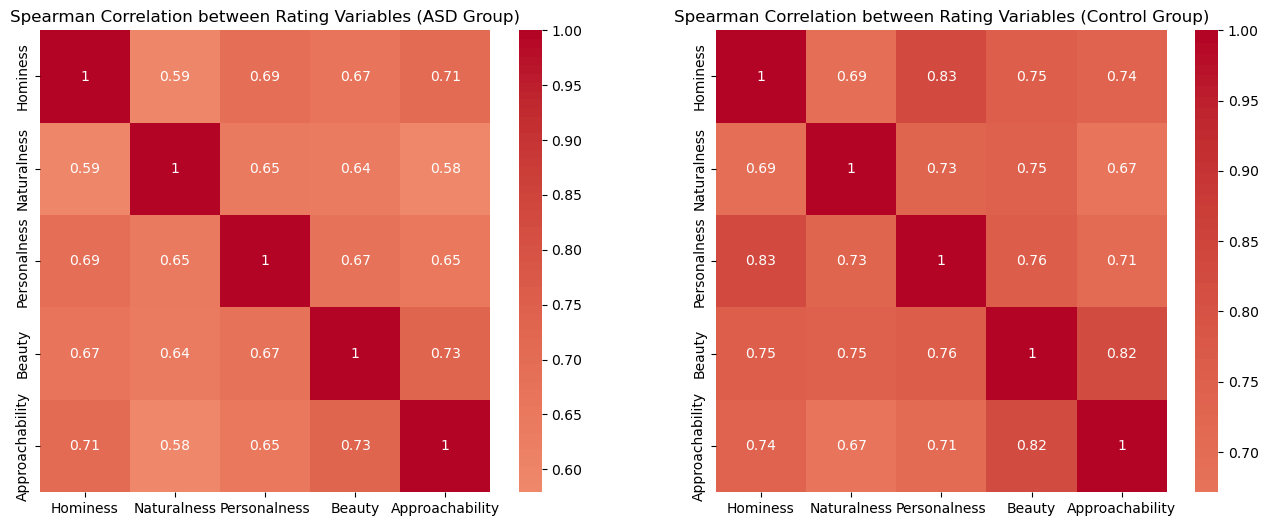

In [63]:
# Plot the heatmap of the correlation matrix for the ASD group (left) and the control group (right)
# Spearman correlation
ASD_corr = ASD_ratings.corr(method="spearman")
CTRL_corr = CTRL_ratings.corr(method="spearman")
# heatmap
plt.figure(figsize=(16,6))
plt.subplot(1, 2, 1)
sns.heatmap(ASD_corr, annot=True, cmap="coolwarm", center=0)
plt.title("Spearman Correlation between Rating Variables (ASD Group)")
plt.subplot(1, 2, 2)
sns.heatmap(CTRL_corr, annot=True, cmap="coolwarm", center=0)
plt.title("Spearman Correlation between Rating Variables (Control Group)")
plt.show()

In [64]:
import pingouin as pg
alpha = pg.cronbach_alpha(data=ASD_ratings)
print("Cronbach’s alpha for ASD group:", alpha)
alpha = pg.cronbach_alpha(data=CTRL_ratings)
print("Cronbach’s alpha for Control group:", alpha)

Cronbach’s alpha for ASD group: (0.9068477511057972, array([0.9  , 0.913]))
Cronbach’s alpha for Control group: (0.9316176786602912, array([0.926, 0.936]))


In [66]:
# load libraries for PCA
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
# Standardize variables and run PCA
X_scaled = StandardScaler().fit_transform(ASD_ratings)
pca = PCA()
X_pca = pca.fit_transform(X_scaled)
explained_var = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)
print("Explained variance ratio:", explained_var)
print("Cumulative explained variance:", cumulative_var)

Explained variance ratio: [0.73049543 0.09293146 0.06987156 0.05846356 0.048238  ]
Cumulative explained variance: [0.73049543 0.82342689 0.89329845 0.951762   1.        ]


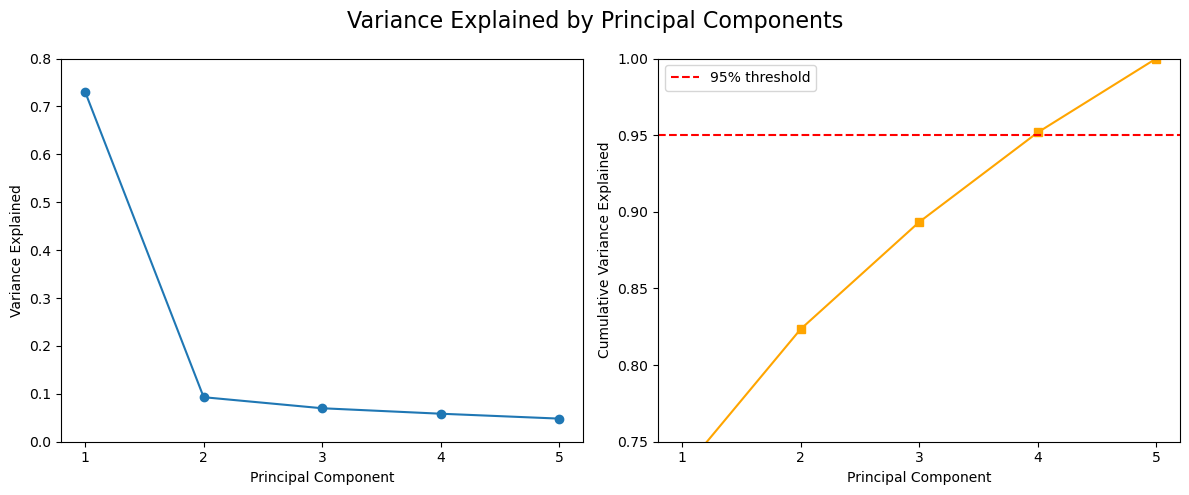

In [67]:
# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(12,5))
# Add a shared title for both subplots
fig.suptitle("Variance Explained by Principal Components", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])

# --- Plot 1: Scree plot ---
axes[0].plot(range(1, len(explained_var)+1), explained_var, marker='o')
axes[0].set_xticks(np.arange(1, len(explained_var)+1, 1))
axes[0].set_xlabel("Principal Component")
axes[0].set_ybound(0, 0.8)
axes[0].set_ylabel("Variance Explained")

# --- Plot 2: Cumulative variance ---
axes[1].plot(range(1, len(cumulative_var)+1), cumulative_var, marker='s', color='orange')
axes[1].axhline(y=0.95, color='r', linestyle='--', label="95% threshold")
axes[1].set_xticks(np.arange(1, len(cumulative_var)+1, 1))
axes[1].set_xlabel("Principal Component")
axes[1].set_ybound(0.75,1)
axes[1].set_ylabel("Cumulative Variance Explained")
axes[1].legend()

plt.tight_layout()
plt.show()
